<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Datascience-for-Economics-Final-Assignment" data-toc-modified-id="Datascience-for-Economics-Final-Assignment-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Datascience for Economics Final Assignment</a></span></li><li><span><a href="#Research-question-(0.5-points)" data-toc-modified-id="Research-question-(0.5-points)-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Research question (0.5 points)</a></span></li><li><span><a href="#Motivation-(0.5-points)" data-toc-modified-id="Motivation-(0.5-points)-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Motivation (0.5 points)</a></span></li><li><span><a href="#Method-and-data-(1.0-point)" data-toc-modified-id="Method-and-data-(1.0-point)-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Method and data (1.0 point)</a></span></li><li><span><a href="#Preview-of-the-answers-(0.5-points)" data-toc-modified-id="Preview-of-the-answers-(0.5-points)-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Preview of the answers (0.5 points)</a></span></li><li><span><a href="#Main-assumptions-(0.5-points)" data-toc-modified-id="Main-assumptions-(0.5-points)-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Main assumptions (0.5 points)</a></span></li><li><span><a href="#Python/R-code-(6-points)" data-toc-modified-id="Python/R-code-(6-points)-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Python code (6 points)</a></span></li><li><span><a href="#Robustness-analysis-(0.5-points)" data-toc-modified-id="Robustness-analysis-(0.5-points)-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Robustness analysis (0.5 points)</a></span></li><li><span><a href="#Discussion-and-conclusion-(0.5-points)" data-toc-modified-id="Discussion-and-conclusion-(0.5-points)-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Discussion and conclusion (0.5 points)</a></span></li></ul></div>

For this problem set, we'll be using the Jupyter notebook:

![](jupyter.png)

# Research Question
What is the effect of social protection expenditure on life expectancy at birth in European Union countries (2012-2021)?

# Motivation

Exploring the relationship between Social Protection Expenditure (per capita) (SPE) and life expectancy at birth is crucial for understanding how government spending on social service’s impacts public health. Life expectancy at birth serves as a key indicator of a population’s overall health [(OECD, 2022)](https://www.oecd.org/en/data/indicators/life-expectancy-at-birth.html#:~:text=Life%20expectancy%20at%20birth%20is%20one%20of%20the%20most%20frequently,access%20to%20quality%20health%20services), influenced by various factors including economic stability, healthcare quality, and lifestyle choices [(OECD, 2022)](https://www.oecd.org/en/data/indicators/life-expectancy-at-birth.html#:~:text=Life%20expectancy%20at%20birth%20is%20one%20of%20the%20most%20frequently,access%20to%20quality%20health%20services). SPEs, such as pensions, unemployment benefits, and healthcare services, play a significant role in reducing poverty, enhancing access to healthcare, and improving living conditions [(Yokobori, 2023)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10177917/).

By studying SPEs alongside other critical variables like GDP per capita, healthcare expenditure, obesity rates, smoking prevalence, and physician availability, researchers can gain insights into the multifaceted drivers of life expectancy. This analysis is particularly important in an era of aging population and rising healthcare costs, where effective allocation of resources is essential. Higher expenditure provides better health services, reduces poverty, and mitigates social risks, all of which contribute to longer lives [(Stuckler et al., 2010)](https://researchonline.lshtm.ac.uk/id/eprint/3268/1/Budget%20crises,%20health,%20and%20social%20welfare%20programmes%20_%20The%20BMJ.pdf). For instance, well-funded pension systems reduce elderly poverty, enhancing quality of life and longevity [(WHO, 2014)](https://www.who.int/health-topics/social-determinants-of-health#tab=tab_1). Studies have found positive correlations between social spending and  life expectancy, especially in OECD countries, where robust welfare programs reduce mortality [(OECD, 2019)](https://www.oecd-ilibrary.org/docserver/e88a7402-en.pdf?expires=1723837255&id=id&accname=guest&checksum=34BC23675C79142AABDAA71BCC69CCD5). Understanding these relationships can help policymakers design more effective social and health policies that contribute to the well-being and longevity of their populations.

# Method and data

The data for our study have been sourced from the Eurostat Database. Hyperlinks for each variable are provided below:
- [Life expectancy at birth](https://ec.europa.eu/eurostat/databrowser/view/tps00205/default/table?lang=en&category=t_demo.t_demo_mor) (years)
- [Social protection expenditure](https://ec.europa.eu/eurostat/databrowser/view/tps00099/default/table?lang=en&category=t_spr) (EUR)
- [Obesity](https://ec.europa.eu/eurostat/databrowser/view/hlth_ehis_bm1e__custom_12598685/default/table?lang=en&page=time:2019) (% of population)
- [Smoking](https://ec.europa.eu/eurostat/databrowser/view/hlth_ehis_sk1e__custom_12598697/default/table?lang=en&page=time:2019) (% of population)
- [GDP per capita](https://ec.europa.eu/eurostat/databrowser/view/nama_10_pc/default/table?lang=en) (EUR)
- [Physicians](https://ec.europa.eu/eurostat/databrowser/view/nama_10_pc/default/table?lang=en) (per 1000 population)
- [Healthcare expenditure](https://ec.europa.eu/eurostat/databrowser/view/hlth_sha11_hp/default/table?lang=en&category=hlth.hlth_care.hlth_sha11.hlth_sha11_sum) (per capita)

After importing the raw data from the Eurostat Database, we filtered it to get the specific timeframe and countries as per our research question, and melted the year columns so that each row of the dataframe corresponds to an observation for a combination of country and year. During this process, we also applied any additional filters as required (e.g. if we wanted the data for all sexes, we dropped entries that are only marked with 'M' or 'F') and then dropped any superfluous columns. We then repeated all the above steps for each of the variables in our regression, merging the results into one large dataset. Finally, we dropped any observations that have missing values, as these prevent the regression from running smoothly.

We ran a two-way fixed effects regression to begin with, and decided to drop a variable and re-estimate after encountering multicollinearity. After running the TWFE model, we decided to use three methods to verify our results: a Lasso regression, a Ridge regression, and Bayesian Analysis. We felt that a neural network would not be particularly useful in our study as our question is one of inference rather than prediction. To that end, we also did not use the Lasso and Ridge regressions to predict any values, but rather to examine how the optimal value of lambda affected our model. All three of our methods required us to standardize our variables around their mean, using their standard deviation to ensure stability in their generating processes. For the Bayesian Analysis, we used the coefficients and standard errors from our TWFE model as the priors.

The data are chiefly representative of the population of interest, as they cover all the EU countries (barring any missing values).

# Preview of the answers

Our two-way fixed effects revealed that social protection expenditure per capita increases life expectancy at birth, with a 1000 euro increase corresponding to a gain of 0.4 years, ceteris paribus (p<0.001). Unexpectedly, obesity and smoking rates were also positively associated with life expectancy, suggesting possible reverse causality or confounding factors in our design. The coefficient for physicians per 1000 was negative but marginally significant, indicating a complex relationship with life expectancy that may require further exploration. These findings bring into question the importance of social investments in public health while also raising questions about the roles of lifestyle factors (smoking and obesity). 

The Lasso regression reported a low optimal lambda while the Ridge regression reported a high optimal lambda, suggesting that the model benefits from shrinking the value of all coefficients rather than eliminating coefficients outright by reducing them to 0. Our Bayesian analysis revealed that the coefficients on the constant and physicians per 1000 may not be very reliable, as the posterior value diverged considerably from the prior. However, it still supported the positive effect of social protection expenditure discovered by the TWFE.

# Main assumptions

One of the main assumptions we have to make is that the missing values in our dataset are not massive outliers that may significantly skew the results of our regressions and analysis. Additionally, it is worth noting that we are working with highly aggregated data at the country level, and as such there may be some error in the estimation of the true values due to information being lost. We also assume that our dataset is not an outlier, but aim to establish this in our study using bootstrapping. Finally, we created a causal diagram to explore the mechanisms through which the effect in question might occur:

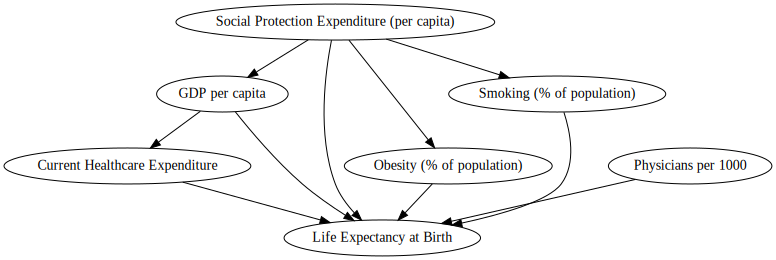

In [2]:
from graphviz import Digraph
causal_diagram = Digraph(comment='Causal Diagram')

#Defining the variables as nodes for the diagram
causal_diagram.node('SPE', 'Social Protection Expenditure (per capita)')
causal_diagram.node('GDP', 'GDP per capita')
causal_diagram.node('CHE', 'Current Healthcare Expenditure')
causal_diagram.node('LEB', 'Life Expectancy at Birth')
causal_diagram.node('OBE', 'Obesity (% of population)')
causal_diagram.node('SMK', 'Smoking (% of population)')
causal_diagram.node('PHY', 'Physicians per 1000')

#Creating the directed edges between the nodes
causal_diagram.edge('SPE', 'GDP')
causal_diagram.edge('SPE', 'OBE')
causal_diagram.edge('GDP', 'CHE')
causal_diagram.edge('CHE', 'LEB')
causal_diagram.edge('SPE', 'LEB')
causal_diagram.edge('OBE', 'LEB')
causal_diagram.edge('SMK', 'LEB')
causal_diagram.edge('PHY', 'LEB')
causal_diagram.edge('GDP', 'LEB')
causal_diagram.edge('SPE', 'SMK')

#Rendering the diagram
causal_diagram.render('causal_diagram', format='png', cleanup=True)
causal_diagram

The causal diagram suggests that social protection expenditure infleunces life expectancy both directly and indirectly through various pathways, including economic development  (GDP), healthcare access (physicians per 1000), and lifestyle factors (obesity and smoking). In particular, we lay out some of the methods through which these pathways exist. For one, Social Protection Expenditure could impact lifestyle factors (smoking and obesity) by organising public health initiatives, such as stronger anti-smoking campaigns or improving access to non-processed food and healthcare. Additionally, physicians (per 1000) could also have a relationship with life expectancy, wherein more physicians generally mean better prevention, early diagnosis, and treatment of diseases.

# Python code

First we import various libraries and packages:

In [3]:
from __future__ import absolute_import, division, print_function, unicode_literals

import numpy as np
import pandas as pd
import seaborn as sn
from scipy import optimize
import pymc3 as pm
import statsmodels.api as sm # check the error that cannot import name 'factorial' in from scipy.misc import factorial
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import tensorflow as tf
import altair as alt
# from linearmodels.iv import IV2SLS
from tensorflow.keras import datasets, layers, models
from tensorflow import keras
import arviz as az

import theano
import covid19pandas as cod
import eurostat
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn import datasets
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import RepeatedKFold
from numpy import arange
from country_codes import eurostat_dictionary

EU_countries = ['Belgium', 'Bulgaria', 'Czechia', 'Denmark',
'Germany (until 1990 former territory of the FRG)', 'Germany','Estonia',
'Ireland', 'Greece', 'Spain', 'France', 'Croatia', 'Italy',
'Cyprus', 'Latvia', 'Lithuania', 'Luxembourg', 'Hungary', 'Malta',
'Netherlands', 'Austria', 'Poland', 'Portugal', 'Romania',
'Slovenia', 'Slovakia', 'Finland', 'Sweden', 'United Kingdom',
'Iceland', 'Liechtenstein', 'Norway', 'Switzerland']

Then we import the data on life expectancy at birth:

In [4]:
df = eurostat.get_data_df('tps00205')
df.head()

,freq,unit,sex,age,geo\TIME_PERIOD,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,A,YR,F,Y_LT1,AL,NaN,80.1,80.1,79.7,80.1,80.1,80.5,80.7,79.6,77.7,80.9,NaN
1,A,YR,F,Y_LT1,AM,NaN,NaN,NaN,78.2,78.4,78.9,79.7,79.7,NaN,NaN,NaN,NaN
2,A,YR,F,Y_LT1,AT,83.6,83.8,84.0,83.7,84.1,84.0,84.1,84.2,83.6,83.7,83.6,84.0
3,A,YR,F,Y_LT1,AZ,76.6,77.1,77.3,77.7,NaN,77.9,78.3,78.9,NaN,NaN,NaN,NaN
4,A,YR,F,Y_LT1,BE,83.1,83.2,83.9,83.4,84.0,83.9,83.9,84.3,83.0,84.3,83.9,84.6


We perform the data cleaning actions as described in the section "Method and Data":

In [5]:
#Replacing the geocodes with country names
df.rename({'geo\TIME_PERIOD': 'geo'},inplace=True,axis = 1)
df['country'] = df['geo'].replace(eurostat_dictionary)

#Filtering for the countries and variables of interest
df.drop(["2023"],axis=1,inplace=True)
df = df[(df.country.isin(EU_countries)) & (df.sex.isin(['T']))]

#Dropping redundant columns
df.drop(['unit','sex','geo','freq','age'],axis=1,inplace=True)

#Melting the time period columns into one column
df = pd.melt(df,id_vars = ['country'],
             value_vars = ["{}".format(year) for year in np.arange(2012,2022)],
             var_name = 'year',
             value_name='life expectancy at birth')
df.head()

,country,year,life expectancy at birth
0,Austria,2012,81.1
1,Belgium,2012,80.5
2,Bulgaria,2012,74.4
3,Switzerland,2012,82.8
4,Cyprus,2012,81.1


We then repeat this process for the remaining variables, merging the results each time:

In [6]:
df_n = eurostat.get_data_df('tps00099')
df_n.head()

,freq,unit,spdeps,geo\TIME_PERIOD,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,A,EUR_HAB_KP10,TOTALNOREROUTE,AL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,436.45,451.43,496.52,518.29
1,A,EUR_HAB_KP10,TOTALNOREROUTE,AT,10461.94,10333.29,10438.41,10515.75,10578.63,10645.87,10757.61,10685.04,10767.78,10926.98,11865.08,11911.18
2,A,EUR_HAB_KP10,TOTALNOREROUTE,BA,NaN,NaN,NaN,697.06,724.61,779.57,873.52,885.77,911.38,NaN,NaN,NaN
3,A,EUR_HAB_KP10,TOTALNOREROUTE,BE,9849.13,9866.62,9785.98,9908.39,10032.36,10178.76,10109.20,10072.22,10110.00,10300.78,11089.89,10932.58
4,A,EUR_HAB_KP10,TOTALNOREROUTE,BG,879.26,896.17,892.81,959.86,1016.82,1024.72,1061.26,1071.27,1122.26,1182.94,1340.04,1472.37


In [7]:
#Replacing the geocodes with country names
df_n.rename({'geo\TIME_PERIOD': 'geo'},inplace=True,axis = 1)
df_n['country'] = df_n['geo'].replace(eurostat_dictionary)

#Filtering for the countries of interest
df_n = df_n[(df_n.country.isin(EU_countries))]

#Dropping redundant columns
df_n.drop(['unit','spdeps','geo','freq'],axis=1,inplace=True)
df_n.drop(["2010","2011"],axis=1,inplace=True)

#Melting the time period columns into distinct entries
df_n = pd.melt(df_n,id_vars = ['country'],
             value_vars = ["{}".format(year) for year in np.arange(2012,2022)],
             var_name = 'year',
             value_name='social protection expenditure per capita (EUR)')
df_n.head()

,country,year,social protection expenditure per capita (EUR)
0,Austria,2012,10438.41
1,Belgium,2012,9785.98
2,Bulgaria,2012,892.81
3,Switzerland,2012,14671.28
4,Cyprus,2012,4462.86


In [8]:
#Merging the results into the main dataframe
df = df.merge(df_n,how='left',left_on=['country','year'],right_on=['country','year'])
df.head()

,country,year,life expectancy at birth,social protection expenditure per capita (EUR)
0,Austria,2012,81.1,10438.41
1,Belgium,2012,80.5,9785.98
2,Bulgaria,2012,74.4,892.81
3,Switzerland,2012,82.8,14671.28
4,Cyprus,2012,81.1,4462.86


In [9]:
df_n = eurostat.get_data_df('hlth_ehis_bm1e')
df_n.head()

,freq,unit,bmi,isced11,sex,age,geo\TIME_PERIOD,2014,2019
0,A,PC,BMI18P5-24,ED0-2,F,TOTAL,AT,45.6,40.9
1,A,PC,BMI18P5-24,ED0-2,F,TOTAL,BE,45.7,41.0
2,A,PC,BMI18P5-24,ED0-2,F,TOTAL,BG,44.3,48.1
3,A,PC,BMI18P5-24,ED0-2,F,TOTAL,CY,43.8,39.6
4,A,PC,BMI18P5-24,ED0-2,F,TOTAL,CZ,42.6,46.2


An important note to make in this case is that we only have obesity data for 2014 and 2019, so we chose to use the 2014 data for all time periods of a given country.

In [10]:
#Replacing the geocodes with country names
df_n.rename({'geo\TIME_PERIOD': 'geo'},inplace=True,axis = 1)
df_n['country'] = df_n['geo'].replace(eurostat_dictionary)

#Filtering for the countries and variables of interest
df_n = df_n[(df_n.country.isin(EU_countries)) & (df_n.age.isin(['TOTAL'])) &\
           (df_n.bmi.isin(['BMI_GE30'])) & (df_n.isced11.isin(['TOTAL'])) &\
           (df_n.sex.isin(['T']))]

#Dropping redundant columns
df_n.drop(['unit','isced11','geo','freq','age','sex','bmi'],axis=1,inplace=True)
df_n.drop(["2019"],axis=1,inplace=True)

#Renaming the remaining column
df_n.rename({'2014': 'obesity (% of population)'},inplace=True,axis = 1)
df_n.head()

,obesity (% of population),country
33370,14.3,Austria
33371,13.7,Belgium
33372,14.4,Bulgaria
33373,13.9,Cyprus
33374,18.7,Czechia


In [11]:
#Merging the results into the main dataframe
df = df.merge(df_n,how='left',left_on=['country'],right_on=['country'])
df.head()

,country,year,life expectancy at birth,social protection expenditure per capita (EUR),obesity (% of population)
0,Austria,2012,81.1,10438.41,14.3
1,Belgium,2012,80.5,9785.98,13.7
2,Bulgaria,2012,74.4,892.81,14.4
3,Switzerland,2012,82.8,14671.28,NaN
4,Cyprus,2012,81.1,4462.86,13.9


In [12]:
df_n = eurostat.get_data_df('hlth_ehis_sk1e')
df_n.head()

,freq,unit,smoking,isced11,sex,age,geo\TIME_PERIOD,2014,2019
0,A,PC,NSM,ED0-2,F,TOTAL,AT,72.3,79.8
1,A,PC,NSM,ED0-2,F,TOTAL,BE,77.8,85.2
2,A,PC,NSM,ED0-2,F,TOTAL,BG,82.2,82.2
3,A,PC,NSM,ED0-2,F,TOTAL,CY,91.4,93.1
4,A,PC,NSM,ED0-2,F,TOTAL,CZ,77.0,77.5


Similarly, we only have 2014 and 2019 data for smoking, so we use the 2014 data for all time periods of a given country. Additionally, this data is calculated; we filtered for the percentage of non-smokers in each country and subtracted that value from 100.

In [13]:
#Replacing the geocodes with country names
df_n.rename({'geo\TIME_PERIOD': 'geo'},inplace=True,axis = 1)
df_n['country'] = df_n['geo'].replace(eurostat_dictionary)

#Filtering for the countries and variables of interest
df_n = df_n[(df_n.country.isin(EU_countries)) & (df_n.age.isin(['TOTAL'])) &\
           (df_n.smoking.isin(['NSM'])) & (df_n.isced11.isin(['TOTAL'])) &\
           (df_n.sex.isin(['T'])) & (df_n.unit.isin(['PC']))]

#Dropping redundant columns
df_n.drop(['unit','isced11','geo','freq','age','sex','smoking'],axis=1,inplace=True)
df_n.drop(["2019"],axis=1,inplace=True)

#Calculating the percentage of the population that smokes
df_n['smoking (% of population)'] = 100 - df_n['2014']
df_n.drop(["2014"],axis=1,inplace=True)
df_n.head()

,country,smoking (% of population)
8393,Austria,30.0
8394,Belgium,23.0
8395,Bulgaria,34.8
8396,Cyprus,29.1
8397,Czechia,28.7


In [14]:
#Merging the results into the main dataframe
df = df.merge(df_n,how='left',left_on=['country'],right_on=['country'])
df.head()

,country,year,life expectancy at birth,social protection expenditure per capita (EUR),obesity (% of population),smoking (% of population)
0,Austria,2012,81.1,10438.41,14.3,30.0
1,Belgium,2012,80.5,9785.98,13.7,23.0
2,Bulgaria,2012,74.4,892.81,14.4,34.8
3,Switzerland,2012,82.8,14671.28,NaN,NaN
4,Cyprus,2012,81.1,4462.86,13.9,29.1


In [15]:
df_n = eurostat.get_data_df('nama_10_pc')
df_n.head()

,freq,unit,na_item,geo\TIME_PERIOD,1975,1976,1977,1978,1979,1980,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,A,CLV10_EUR_HAB,B1GQ,AL,NaN,NaN,NaN,NaN,NaN,NaN,...,3330.0,3410.0,3530.0,3670.0,3830.0,3920.0,3810.0,NaN,NaN,NaN
1,A,CLV10_EUR_HAB,B1GQ,AT,NaN,NaN,NaN,NaN,NaN,NaN,...,36130.0,36140.0,36390.0,36980.0,37690.0,38070.0,35390.0,36740.0,38080.0,37460.0
2,A,CLV10_EUR_HAB,B1GQ,BE,NaN,NaN,NaN,NaN,NaN,NaN,...,33870.0,34360.0,34620.0,35050.0,35510.0,36110.0,34050.0,36260.0,37050.0,37300.0
3,A,CLV10_EUR_HAB,B1GQ,BG,NaN,NaN,NaN,NaN,NaN,NaN,...,5470.0,5700.0,5910.0,6120.0,6330.0,6630.0,6400.0,6950.0,7680.0,7850.0
4,A,CLV10_EUR_HAB,B1GQ,CH,NaN,NaN,NaN,NaN,NaN,NaN,...,59300.0,59600.0,60170.0,60420.0,61690.0,61950.0,60190.0,62950.0,64030.0,63680.0


In [16]:
#Replacing the geocodes with country names
df_n.rename({'geo\TIME_PERIOD': 'geo'},inplace=True,axis = 1)
df_n['country'] = df_n['geo'].replace(eurostat_dictionary)

#Filtering for the countries and variables of interest
df_n = df_n[(df_n.country.isin(EU_countries)) & (df_n.unit.isin(['CP_EUR_HAB'])) &\
            (df_n.na_item.isin(['B1GQ']))]

#Dropping redundant columns
df_n.drop(['unit','na_item','geo','freq'],axis=1,inplace=True)
df_n.drop(["{}".format(year) for year in np.arange(1975,2012)],axis=1,inplace=True)
df_n.drop(["{}".format(year) for year in np.arange(2022,2024)],axis=1,inplace=True)

#Melting the time period columns into distinct entries
df_n = pd.melt(df_n,id_vars = ['country'],
             value_vars = ["{}".format(year) for year in np.arange(2012,2022)],
             var_name = 'year',
             value_name='GDP per capita (EUR)')
df_n.head()

,country,year,GDP per capita (EUR)
0,Austria,2012,37820.0
1,Belgium,2012,34770.0
2,Bulgaria,2012,5780.0
3,Switzerland,2012,66780.0
4,Cyprus,2012,22570.0


In [17]:
#Merging the results into the main dataframe
df = df.merge(df_n,how='left',left_on=['country','year'],right_on=['country','year'])
df.head()

,country,year,life expectancy at birth,social protection expenditure per capita (EUR),obesity (% of population),smoking (% of population),GDP per capita (EUR)
0,Austria,2012,81.1,10438.41,14.3,30.0,37820.0
1,Belgium,2012,80.5,9785.98,13.7,23.0,34770.0
2,Bulgaria,2012,74.4,892.81,14.4,34.8,5780.0
3,Switzerland,2012,82.8,14671.28,NaN,NaN,66780.0
4,Cyprus,2012,81.1,4462.86,13.9,29.1,22570.0


In [18]:
df_n = eurostat.get_data_df('hlth_rs_phys')
df_n.head()

,freq,unit,age,sex,geo\TIME_PERIOD,1980,1981,1982,1983,1984,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,A,NR,TOTAL,F,AT,NaN,NaN,NaN,NaN,NaN,...,19313.0,19873.0,20418.0,21024.0,21549.0,22020.0,22664.0,23061.0,23745.0,24272.0
1,A,NR,TOTAL,F,BE,NaN,NaN,NaN,NaN,NaN,...,12686.0,13174.0,13822.0,14515.0,15049.0,15732.0,16317.0,17039.0,17652.0,18266.0
2,A,NR,TOTAL,F,BG,NaN,NaN,NaN,NaN,NaN,...,NaN,15971.0,15984.0,16232.0,16439.0,16490.0,16536.0,16549.0,16503.0,16532.0
3,A,NR,TOTAL,F,CH,NaN,NaN,NaN,NaN,NaN,...,12657.0,13418.0,14100.0,14774.0,15316.0,15785.0,16175.0,16694.0,17373.0,18040.0
4,A,NR,TOTAL,F,CY,NaN,NaN,NaN,NaN,NaN,...,NaN,1072.0,1145.0,1205.0,1256.0,1347.0,1439.0,1588.0,1716.0,1876.0


In [19]:
#Replacing the geocodes with country names
df_n.rename({'geo\TIME_PERIOD': 'geo'},inplace=True,axis = 1)
df_n['country'] = df_n['geo'].replace(eurostat_dictionary)

#Filtering for the countries and variables of interest
df_n = df_n[(df_n.country.isin(EU_countries)) & (df_n.age.isin(['TOTAL'])) &\
            (df_n.sex.isin(['T']))]

#Dropping redundant columns
df_n.drop(['unit','age','geo','freq','sex'],axis=1,inplace=True)
df_n.drop(["{}".format(year) for year in np.arange(1980,2012)],axis=1,inplace=True)
df_n.drop(["2022"],axis=1,inplace=True)

#Melting the time period columns into distinct entries
df_n = pd.melt(df_n,id_vars = ['country'],
             value_vars = ["{}".format(year) for year in np.arange(2012,2022)],
             var_name = 'year',
             value_name='physicians')
df_n.head()

,country,year,physicians
0,Austria,2012,41076.0
1,Belgium,2012,32583.0
2,Bulgaria,2012,NaN
3,Switzerland,2012,31313.0
4,Cyprus,2012,NaN


However, it is not advisable to simply use the number of physicians as an explanatory variable, as this would obviously be influenced by the size of each country. Thus, we chose to standardize this by calculating the number of physicians per 1000 population below:

In [20]:
df_o = eurostat.get_data_df('demo_pjan')
df_o.head()

,freq,unit,age,sex,geo\TIME_PERIOD,1960,1961,1962,1963,1964,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,A,NR,TOTAL,F,AD,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,37388.0,NaN,NaN,NaN,NaN
1,A,NR,TOTAL,F,AL,NaN,NaN,NaN,NaN,NaN,...,1430827.0,1424597.0,1417141.0,1423050.0,1431715.0,1432833.0,1425342.0,1419759.0,1406532.0,1394864.0
2,A,NR,TOTAL,F,AM,NaN,NaN,NaN,NaN,NaN,...,NaN,1571450.0,1569535.0,1567380.0,1564533.0,1563538.0,1562689.0,1565144.0,NaN,1571757.0
3,A,NR,TOTAL,F,AT,3757167.0,3773097.0,3794130.0,3814191.0,3836415.0,...,4352447.0,4384529.0,4427918.0,4460424.0,4483749.0,4501742.0,4522292.0,4535712.0,4553444.0,4619957.0
4,A,NR,TOTAL,F,AZ,NaN,NaN,NaN,NaN,NaN,...,4763571.0,4817181.0,4870002.0,4918771.0,4960058.0,4999053.0,5039100.0,5065288.0,5081846.0,NaN


In [21]:
#Replacing the geocodes with country names
df_o.rename({'geo\TIME_PERIOD': 'geo'},inplace=True,axis = 1)
df_o['country'] = df_o['geo'].replace(eurostat_dictionary)

#Filtering for the countries and variables of interest
df_o = df_o[(df_o.country.isin(EU_countries)) & (df_o.age.isin(['TOTAL'])) &\
            (df_o.sex.isin(['T']))]

#Dropping redundant columns
df_o.drop(['unit','age','geo','freq','sex'],axis=1,inplace=True)
df_o.drop(["{}".format(year) for year in np.arange(1960,2012)],axis=1,inplace=True)
df_o.drop(["2022","2023"],axis=1,inplace=True)

#Melting the time period columns into distinct entries
df_o = pd.melt(df_o,id_vars = ['country'],
             value_vars = ["{}".format(year) for year in np.arange(2012,2022)],
             var_name = 'year',
             value_name='population')
df_o.head()

,country,year,population
0,Austria,2012,8408121.0
1,Belgium,2012,11075889.0
2,Bulgaria,2012,7327224.0
3,Switzerland,2012,7954662.0
4,Cyprus,2012,862011.0


In [22]:
#Merging the results into the temporary dataframe
df_n = df_n.merge(df_o,how='left',left_on=['country','year'],right_on=['country','year'])

#Calculating the column of interest
df_n['physicians per 1000'] = df_n['physicians']*1000/df_n['population']

#Dropping redundant columns
df_n.drop(['physicians','population'],axis=1,inplace=True)
df_n.head()

,country,year,physicians per 1000
0,Austria,2012,4.885277
1,Belgium,2012,2.941795
2,Bulgaria,2012,NaN
3,Switzerland,2012,3.936434
4,Cyprus,2012,NaN


In [23]:
#Merging the results into the main dataframe
df = df.merge(df_n,how='left',left_on=['country','year'],right_on=['country','year'])
df.head()

,country,year,life expectancy at birth,social protection expenditure per capita (EUR),obesity (% of population),smoking (% of population),GDP per capita (EUR),physicians per 1000
0,Austria,2012,81.1,10438.41,14.3,30.0,37820.0,4.885277
1,Belgium,2012,80.5,9785.98,13.7,23.0,34770.0,2.941795
2,Bulgaria,2012,74.4,892.81,14.4,34.8,5780.0,NaN
3,Switzerland,2012,82.8,14671.28,NaN,NaN,66780.0,3.936434
4,Cyprus,2012,81.1,4462.86,13.9,29.1,22570.0,NaN


In [24]:
df_n = eurostat.get_data_df('hlth_sha11_hp')
df_n.head()

,freq,unit,icha11_hp,geo\TIME_PERIOD,1992,1993,1994,1995,1996,1997,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,A,EUR_HAB,HP1,AT,NaN,NaN,NaN,NaN,NaN,NaN,...,1548.07,1570.39,1622.48,1675.07,1738.35,1820.28,1914.89,2000.71,2065.71,NaN
1,A,EUR_HAB,HP1,BA,NaN,NaN,NaN,NaN,NaN,NaN,...,124.57,133.71,142.85,146.39,160.82,NaN,NaN,NaN,NaN,NaN
2,A,EUR_HAB,HP1,BE,NaN,NaN,NaN,NaN,NaN,NaN,...,1387.07,1479.64,1496.60,1553.23,1579.27,1735.85,1840.81,1903.09,1992.75,NaN
3,A,EUR_HAB,HP1,BG,NaN,NaN,NaN,NaN,NaN,NaN,...,175.83,173.87,188.25,204.57,226.39,234.27,300.21,340.85,363.07,NaN
4,A,EUR_HAB,HP1,CH,NaN,NaN,NaN,NaN,NaN,NaN,...,2570.12,2971.24,2995.99,2951.04,2840.66,3018.25,3152.32,3233.52,NaN,NaN


In [25]:
#Replacing the geocodes with country names
df_n.rename({'geo\TIME_PERIOD': 'geo'},inplace=True,axis = 1)
df_n['country'] = df_n['geo'].replace(eurostat_dictionary)

#Filtering for the countries and variables of interest
df_n = df_n[(df_n.country.isin(EU_countries)) & (df_n.unit.isin(['EUR_HAB'])) &\
            (df_n.icha11_hp.isin(['TOTAL']))]

#Dropping redundant columns
df_n.drop(['unit','icha11_hp','geo','freq',],axis=1,inplace=True)
df_n.drop(["{}".format(year) for year in np.arange(1992,2012)],axis=1,inplace=True)
df_n.drop(["2022","2023"],axis=1,inplace=True)

#Melting the time period columns into distinct entries
df_n = pd.melt(df_n,id_vars = ['country'],
             value_vars = ["{}".format(year) for year in np.arange(2012,2022)],
             var_name = 'year',
             value_name='healthcare expenditure per capita (EUR)')
df_n.head()

,country,year,healthcare expenditure per capita (EUR)
0,Austria,2012,3855.27
1,Belgium,2012,3651.59
2,Bulgaria,2012,436.06
3,Switzerland,2012,6774.25
4,Cyprus,2012,1474.97


In [26]:
#Merging the results into the main dataframe
df = df.merge(df_n,how='left',left_on=['country','year'],right_on=['country','year'])
df.head()

,country,year,life expectancy at birth,social protection expenditure per capita (EUR),obesity (% of population),smoking (% of population),GDP per capita (EUR),physicians per 1000,healthcare expenditure per capita (EUR)
0,Austria,2012,81.1,10438.41,14.3,30.0,37820.0,4.885277,3855.27
1,Belgium,2012,80.5,9785.98,13.7,23.0,34770.0,2.941795,3651.59
2,Bulgaria,2012,74.4,892.81,14.4,34.8,5780.0,NaN,436.06
3,Switzerland,2012,82.8,14671.28,NaN,NaN,66780.0,3.936434,6774.25
4,Cyprus,2012,81.1,4462.86,13.9,29.1,22570.0,NaN,1474.97


Finally, we drop the empty rows and export the dataframe to be uploaded onto GitHub:

In [27]:
df = df.dropna()
df.to_csv('dataframe_resit.csv')

Now that we have gathered and cleaned the data required for our analysis, it is important to show that the sample we are working with is unlikely to be an outlier. To do this, we conduct the process of bootstrapping, wherein we resample multiple times from our dataset with replacement and plot a distribution of the bootstrap means we obtain. Then, we compare a 95% confidence interval around the bootstrap means against our original sample mean to determine if our sample is an outlier or not:

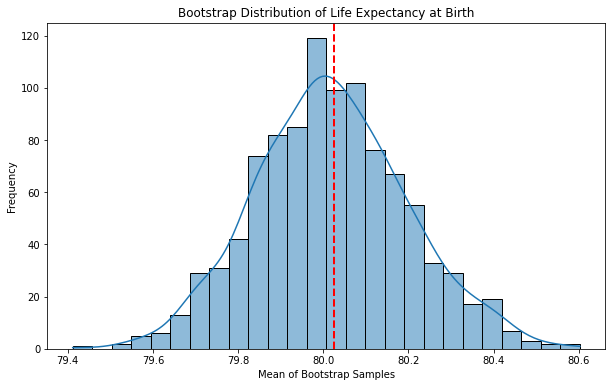

95.0% confidence interval for the mean: [79.68240842490843, 80.39312271062272]
,The original sample mean is: 80.02454212454212
,The original sample mean is not an outlier.


In [28]:
num_bootstrap_samples = 1000
alpha = 0.05  # significance level

# Function for creating bootstrap samples and calculating the mean
def bootstrap_sample(data, num_samples):
    bootstrap_means = []
    for i in range(num_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.mean(sample))
    return bootstrap_means

# Calling the above function and storing the results
bootstrap_means = bootstrap_sample(df['life expectancy at birth'], num_bootstrap_samples)

# Calculate the empirical mean and standard deviation of the bootstrap samples
mean_bootstrap = np.mean(bootstrap_means)
std_bootstrap = np.std(bootstrap_means)

# Plotting the bootstrap distribution
plt.figure(figsize=(10, 6))
sn.histplot(bootstrap_means, kde=True)
plt.axvline(np.mean(df['life expectancy at birth']), color='red', linestyle='dashed', linewidth=2)
plt.title('Bootstrap Distribution of Life Expectancy at Birth')
plt.xlabel('Mean of Bootstrap Samples')
plt.ylabel('Frequency')
plt.show()

# Calculating the confidence interval
lower_bound = np.percentile(bootstrap_means, alpha/2*100)
upper_bound = np.percentile(bootstrap_means, (1-alpha/2)*100)
print(f"{100*(1-alpha)}% confidence interval for the mean: [{lower_bound}, {upper_bound}]")

# Check if the original sample mean is outside the confidence interval
original_mean = np.mean(df['life expectancy at birth'])
print(f"The original sample mean is: {original_mean}")
if original_mean < lower_bound or original_mean > upper_bound:
    print("The original sample mean is an outlier.")
else:
    print("The original sample mean is not an outlier.")

Thus, we can safely proceed with our analysis, confident that our sample is unlikely to be an outlier. We now run the TWFE regression. The two-way fixed effects regression analysis explores the impact of social protection expenditure on life expectancy across mutiple countries over time, controlling key socioeconomic and health-related factors. The model accounts for both country-specific and time-specific effects. 

In [29]:
import statsmodels.formula.api as smf

model_formula = 'Q("life expectancy at birth") ~ Q("social protection expenditure per capita (EUR)") + Q("obesity (% of population)") + Q("smoking (% of population)") + Q("physicians per 1000") + Q("GDP per capita (EUR)") + Q("healthcare expenditure per capita (EUR)") + C(country) + C(year)'
model = smf.ols(formula=model_formula, data=df).fit()
model_summary = model.summary()
model_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                 
=========================================================================================
Dep. Variable:     Q("life expectancy at birth")   R-squared:                       0.982
Model:                                       OLS   Adj. R-squared:                  0.979
Method:                            Least Squares   F-statistic:                     301.4
Date:                           Fri, 16 Aug 2024   Prob (F-statistic):          2.20e-178
Time:                                   21:03:00   Log-Likelihood:                -130.26
No. Observations:                            273   AIC:                             346.5
Df Residuals:                                230   BIC:                             501.7
Df Model:                                     42                                         
Covariance Type:                       nonrobust                                         
=======================================================================================================================
                                                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                              27.9749      1.029     27.176      0.000      25.947      30.003
C(country)[T.Belgium]                                   6.9033      0.249     27.751      0.000       6.413       7.393
C(country)[T.Bulgaria]                                 -8.3949      1.161     -7.231      0.000     -10.682      -6.107
C(country)[T.Croatia]                                  -5.3904      0.673     -8.008      0.000      -6.717      -4.064
C(country)[T.Cyprus]                                    4.2158      0.661      6.380      0.000       2.914       5.518
C(country)[T.Czechia]                                  -6.1691      0.593    -10.409      0.000      -7.337      -5.001
C(country)[T.Denmark]                                   5.7974      0.779      7.440      0.000       4.262       7.333
C(country)[T.Estonia]                                  -6.9120      0.601    -11.505      0.000      -8.096      -5.728
C(country)[T.Finland]                                   4.0252      0.509      7.910      0.000       3.023       5.028
C(country)[T.France]                                    1.3960      0.390      3.583      0.000       0.628       2.164
C(country)[T.Germany]                                   3.7778      0.296     12.781      0.000       3.195       4.360
C(country)[T.Greece]                                   -3.8162      0.664     -5.745      0.000      -5.125      -2.507
C(country)[T.Hungary]                                 -10.3429      0.572    -18.080      0.000     -11.470      -9.216
C(country)[T.Iceland]                                   6.0857      0.310     19.611      0.000       5.474       6.697
C(country)[T.Ireland]                                   1.7224      0.280      6.152      0.000       1.171       2.274
C(country)[T.Italy]                                    15.1151      0.336     45.044      0.000      14.454      15.776
C(country)[T.Latvia]                                  -13.4890      0.663    -20.337      0.000     -14.796     -12.182
C(country)[T.Lithuania]                                -2.1094      0.735     -2.869      0.004      -3.558      -0.661
C(country)[T.Luxembourg]                                4.8598      1.433      3.391      0.001       2.036       7.683
C(country)[T.Malta]                                    -8.2124      0.286    -28.734      0.000      -8.776      -7.649
C(country)[T.Netherlands]                               5.8920      0.312     18.870      0.000       5.277       6.507
C(country)[T.Norway]                                    9.8788      0.966     10.2

Before interpreting the coefficients of this model, it is worth noting the warning of potential multicollinearity under the regression table, which can drastically reduce the reliability of our coefficients and the quality of our inference. Since we are working with highly aggregated macroeconomic data, many of which tend to be indicators of health and economic prosperity, some multicollinearity is inevitable. However, we can still try to address this issue using the Variance Inflation Factor (VIF) check below:

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['social protection expenditure per capita (EUR)', 
        'obesity (% of population)', 
        'smoking (% of population)', 
        'physicians per 1000', 
        'GDP per capita (EUR)', 
        'healthcare expenditure per capita (EUR)']]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

                                          feature        VIF
,0  social protection expenditure per capita (EUR)  40.990909
,1                       obesity (% of population)  22.132378
,2                       smoking (% of population)  31.958224
,3                             physicians per 1000  27.550358
,4                            GDP per capita (EUR)  24.108642
,5         healthcare expenditure per capita (EUR)  46.220709


As can be seen from the VIF table above, there is a high presence of multicollinearity in our model (as a rule of thumb, VIF values over 10 suggest the presence of multicollinearity). From our economic knowledge, it seems most likely that healthcare expenditure per capita is highly correlated with social protection expenditure per capita, as a large portion of social protection expenditure goes towards the elderly in the form of pensions, who often avail healthcare services. Sure enough, dropping healthcare expenditure per capita from our model brings down the VIF value for our explanatory variable considerably: 

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['social protection expenditure per capita (EUR)', 
        'obesity (% of population)', 
        'smoking (% of population)', 
        'physicians per 1000', 
        'GDP per capita (EUR)']]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

                                          feature        VIF
,0  social protection expenditure per capita (EUR)  19.587355
,1                       obesity (% of population)  21.334948
,2                       smoking (% of population)  27.712811
,3                             physicians per 1000  24.811749
,4                            GDP per capita (EUR)  21.474371


While the VIF values are still not ideal, we were not confident about dropping other variables without reasoning grounded in economic theory as to why they could be causing multicollinearity. Now, we re-estimate our model after having dropped healthcare expenditure per capita:

In [32]:
model_formula = 'Q("life expectancy at birth") ~ Q("social protection expenditure per capita (EUR)") + Q("obesity (% of population)") + Q("smoking (% of population)") + Q("physicians per 1000") + Q("GDP per capita (EUR)") + C(country) + C(year)'
model = smf.ols(formula=model_formula, data=df).fit()
model_summary = model.summary()
model_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                 
=========================================================================================
Dep. Variable:     Q("life expectancy at birth")   R-squared:                       0.982
Model:                                       OLS   Adj. R-squared:                  0.979
Method:                            Least Squares   F-statistic:                     309.8
Date:                           Fri, 16 Aug 2024   Prob (F-statistic):          1.40e-179
Time:                                   21:03:01   Log-Likelihood:                -130.41
No. Observations:                            273   AIC:                             344.8
Df Residuals:                                231   BIC:                             496.4
Df Model:                                     41                                         
Covariance Type:                       nonrobust                                         
=======================================================================================================================
                                                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                              27.7743      0.943     29.461      0.000      25.917      29.632
C(country)[T.Belgium]                                   6.9138      0.247     27.945      0.000       6.426       7.401
C(country)[T.Bulgaria]                                 -8.2415      1.116     -7.385      0.000     -10.440      -6.043
C(country)[T.Croatia]                                  -5.3925      0.672     -8.025      0.000      -6.717      -4.068
C(country)[T.Cyprus]                                    4.2722      0.650      6.577      0.000       2.992       5.552
C(country)[T.Czechia]                                  -6.0875      0.568    -10.722      0.000      -7.206      -4.969
C(country)[T.Denmark]                                   5.6342      0.703      8.013      0.000       4.249       7.020
C(country)[T.Estonia]                                  -6.8219      0.571    -11.949      0.000      -7.947      -5.697
C(country)[T.Finland]                                   3.9277      0.468      8.401      0.000       3.007       4.849
C(country)[T.France]                                    1.3622      0.383      3.558      0.000       0.608       2.116
C(country)[T.Germany]                                   3.7872      0.294     12.861      0.000       3.207       4.367
C(country)[T.Greece]                                   -3.7768      0.658     -5.737      0.000      -5.074      -2.480
C(country)[T.Hungary]                                 -10.2669      0.550    -18.680      0.000     -11.350      -9.184
C(country)[T.Iceland]                                   6.1040      0.308     19.847      0.000       5.498       6.710
C(country)[T.Ireland]                                   1.7115      0.279      6.143      0.000       1.163       2.261
C(country)[T.Italy]                                    15.1042      0.334     45.186      0.000      14.446      15.763
C(country)[T.Latvia]                                  -13.3951      0.634    -21.134      0.000     -14.644     -12.146
C(country)[T.Lithuania]                                -2.0079      0.704     -2.852      0.005      -3.395      -0.621
C(country)[T.Luxembourg]                                4.3903      1.063      4.131      0.000       2.297       6.484
C(country)[T.Malta]                                    -8.1213      0.216    -37.531      0.000      -8.548      -7.695
C(country)[T.Netherlands]                               5.8500      0.300     19.518      0.000       5.259       6.441
C(country)[T.Norway]                                    9.7169      0.906     10.7

The coefficient for social protection expenditure is around 0.0004 with a p-value of 0.000, indicating that higher expenditure is associated with incresed life expectancy, but the apparently small magnitude of this effect needs to be considered in the appropriate context. To truly grasp this effect, we first find the mean of social protection expenditure per capita in our dataset:

In [33]:
print(np.mean(df['social protection expenditure per capita (EUR)']))

7133.163443223443


If the mean country were to increase their social protection expenditure per capita by only 10%, our TWFE model predicts that, ceteris paribus, life expectancy at birth would increase by 0.29 years. This is not a negligible amount, affirming the importance of social protection expenditure in healthcare outcomes.

However, the model also reveals unexpected positive associations between obesity and smoking rated with life expectancy. The coefficient for obesity is approximately 1.5587 (p-value 0.000), and for smoking, it is around 0.9373 (p-value 00.000). These counterintuitive results could be due to muticollinearity or reverse causality (more in the discussion). 

The coefficient for physicians per 100 is negative (-0.3235) with a marginal significance (p=value 0.058),indicating a complex relationship that requires further exploration. 

The model explains a very high proportion of the variance in life expectancy, With an R-sqaured of 0.982, but the positive associations for obesity and smoking are puzzling and merit further examination.

A key concern that still remains after re-estimation is the problem of overfitting. Thus, we argue it would be germane to run Lasso and Ridge regressions to see how penalizing the addition of variables could affect our results. To that end, we standardize each variable using its mean and standard deviation to be used in the Lasso and Ridge regressions, and to improve the stability of the NUTS sampler used in the Bayesian Analysis later in the assignment.

In [34]:
df['life expectancy at birth'] = (df['life expectancy at birth'] - df['life expectancy at birth'].mean()) / df['life expectancy at birth'].std()
df['social protection expenditure per capita (EUR)'] = (df['social protection expenditure per capita (EUR)'] - df['social protection expenditure per capita (EUR)'].mean()) / df['social protection expenditure per capita (EUR)'].std()
df['obesity (% of population)'] = (df['obesity (% of population)'] - df['obesity (% of population)'].mean()) / df['obesity (% of population)'].std()
df['smoking (% of population)'] = (df['smoking (% of population)'] - df['smoking (% of population)'].mean()) / df['smoking (% of population)'].std()
df['physicians per 1000'] = (df['physicians per 1000'] - df['physicians per 1000'].mean()) / df['physicians per 1000'].std()
df['GDP per capita (EUR)'] = (df['GDP per capita (EUR)'] - df['GDP per capita (EUR)'].mean()) / df['GDP per capita (EUR)'].std()
df['healthcare expenditure per capita (EUR)'] = (df['healthcare expenditure per capita (EUR)'] - df['healthcare expenditure per capita (EUR)'].mean()) / df['healthcare expenditure per capita (EUR)'].std()

We run the Lasso regression, using a method called k-fold Cross Validation to determine the value of lambda that minimizes the mean squared error (MSE). We test all values of lambda between 0 and 1, with steps of 0.01: 

In [35]:
#define predictor and response variables
X = df[["social protection expenditure per capita (EUR)", "obesity (% of population)", "smoking (% of population)", "physicians per 1000", "GDP per capita (EUR)"]]
y = df["life expectancy at birth"]

#define cross-validation method to evaluate model
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

#define model
model_lasso = LassoCV(alphas=arange(0, 1, 0.01), cv=cv, n_jobs=-1)

#fit model
model_lasso.fit(X, y)

#display lambda that produced the lowest test MSE
print(f"The value of lambda that minimizes MSE is: {model_lasso.alpha_}")

The value of lambda that minimizes MSE is: 0.0


Repeating this process with a Ridge regression gives us:

In [36]:
#define predictor and response variables
X = df[["social protection expenditure per capita (EUR)", "obesity (% of population)", "smoking (% of population)", "physicians per 1000", "GDP per capita (EUR)"]]
y = df["life expectancy at birth"]

#define cross-validation method to evaluate model
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

#define model
model_ridge = RidgeCV(alphas=arange(0, 1, 0.01), cv=cv, scoring='neg_mean_absolute_error')

#fit model
model_ridge.fit(X, y)

#display lambda that produced the lowest test MSE
print(f"The value of lambda that minimizes MSE is: {model_ridge.alpha_}")

The value of lambda that minimizes MSE is: 0.99


It is important to note that the Lasso and Ridge regressions both determined vastly different values of lambda to be optimal. The Lasso regression minimizes $RSS + \lambda\sum|\beta_j|$ while the Ridge regression minimizes $RSS + \lambda\sum{\beta^2}$. As such, the Lasso regression is much more inclined to reduce coefficients to zero than the Ridge regression. Thus, this difference in optimal lambda, where the Lasso regression reports a lambda of 0, while the Ridge reports a lambda of 0.99, could suggest that the model benefits from reducing the effect of all variables (such as in the case where there is multicollinearity) rather than eliminating the effect of some variables outright (i.e. reducing their coefficients to 0). This suggests that the presence of overfitting is limited only to an upward bias in the value of the coefficients, and that we have not included any superfluous variables.

# Robustness analysis

We run the Bayesian Analysis sampler, using the TWFE coefficients and standard errors as the priors:

In [37]:
with pm.Model() as model_simulated_data:
    constant = pm.Normal('constant',27.8,0.9)
    slope1 = pm.Normal('slope1',0.0004,0.0001)
    slope2 = pm.Normal('slope2',1.56,0.05)
    slope3 = pm.Normal('slope3',0.94,0.04)
    slope4 = pm.Normal('slope4',-0.33,0.17)
    slope5 = pm.Normal('slope5',0,0.0001)
    sigma = pm.HalfNormal('sigma',1)
    obs = pm.Normal('obs',mu = constant + slope1*df['social protection expenditure per capita (EUR)'] + slope2*df['obesity (% of population)'] + \
                    slope3*df['smoking (% of population)'] + slope4*df['physicians per 1000'] + slope5*df['GDP per capita (EUR)'], sigma = sigma, observed = df['life expectancy at birth'])
    trace = pm.sample(1000, tune=2000)

Auto-assigning NUTS sampler...
,Initializing NUTS using jitter+adapt_diag...
,Multiprocess sampling (4 chains in 4 jobs)
,NUTS: [sigma, slope5, slope4, slope3, slope2, slope1, constant]


Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 117 seconds.


Then, we plot the results:

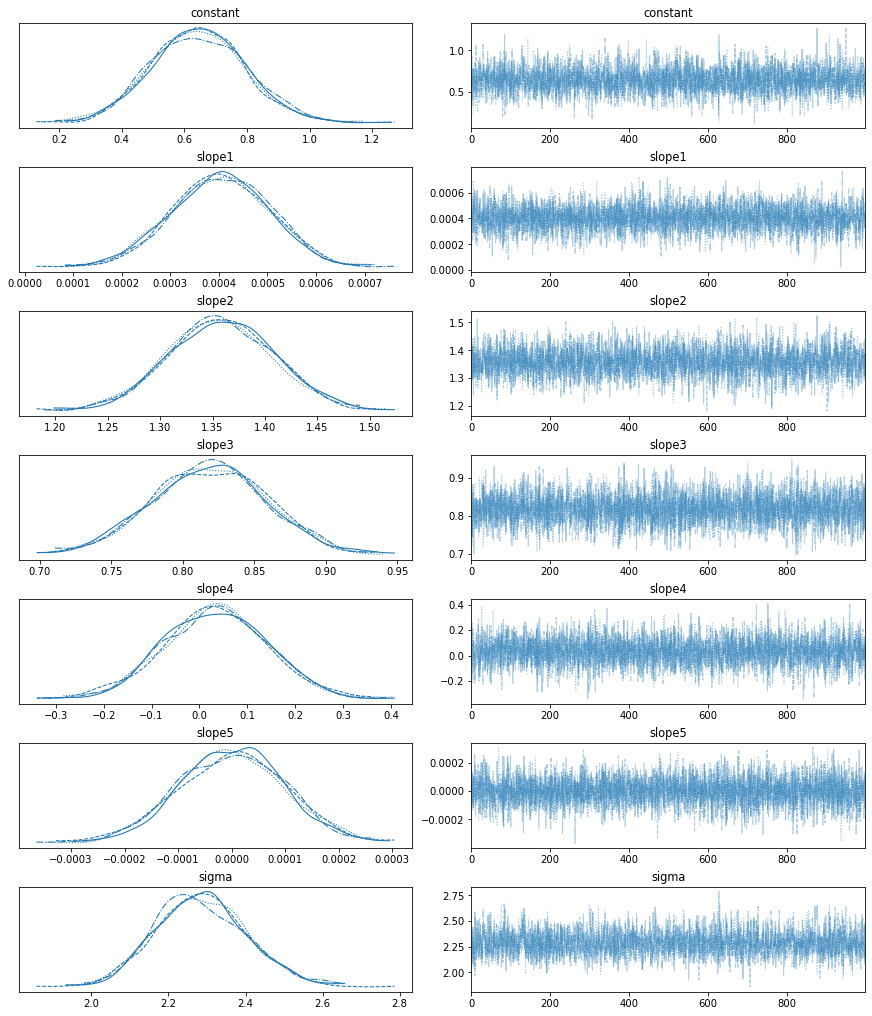

In [38]:
with model_simulated_data:
    pm.plot_trace(trace)

The right side trace plot for each variable shows signs of being robust, as it moves up and down, not lingering at any specific value for multiple iterations. Additionally, visual inspection also shows that it roughly oscillates around a mean value, and does not take a net upward or downward trajectory throughout its iterations. As for the left side plot, the peaks of the slope and constant values compare to the TWFE coefficients as follows, in the form (prior, posterior):

- Constant: (0.6,27.8)
- social protection expenditure per capita (EUR): (0.0004, 0.0004)
- obesity (% of population): (1.56, 1.37)
- smoking (% of population): (0.94, 0.83)
- physicians per 1000: (-0.33, 0.02)
- GDP per capita (EUR): (0,0)

The standout results here are those of the constant and physicians per 1000, both of which have diverged significantly from the prior values. This large change could be due to the aforementioned problem of multicollinearity in our model, or due to the standardization process of the data, which we conducted after running the TWFE regression. Ultimately, however, the Bayesian Analysis supports our estimate of 0.0004 for the effect of our main independent variable, which is social protection expenditure per capita.

While the results of the Lasso and Ridge regression (both of which automatically split the data into train and validation sets using the k-fold cross validation method) may have suggested an upward bias in the value of the coefficients of our regression, the Bayesian Analysis above helps lend credence to the main finding of our study - the non-trivial effect of social protection expenditure on life expectancy at birth.

# Discussion and conclusion

To conclude, the effect of social protection expenditure on life expectancy at birth for countries in the European Union for the period 2012-2021 is positive and statistically significant - a 1000 euro increase corresponding to a gain of 0.4 years, ceteris paribus. This is a considerable effect, hinting at the potential utility of social protection expenditure as a policymaking tool in the healthcare context. This result is hindered however, by the presence of multicollinearity in our TWFE specification and the results of the Lasso and Ridge regression. Thus, it is hard to make any definitive causal claims from our study.

The unexpected positive associations between obesity, smoking, and life expectancy suggest the possibility of reverse causality. For instance, higher life expectancy might be leading to higher observed rates of obesity and smoking (older populations having more time to develop these conditions). Although, this effect can be considered relatively weak specifically for smoking as its a habit thats developed in a younger age. There could also be some counfounding varibles like pre-existing public health interventions.

The focused nature of our study is a double-edged sword, as the results provide insights that are relevant to the European Union, but may not be easily generalizable to other contexts due to varying cultural contexts and healthcare infrastructure. Moreover, it is possible that we may have neglected some key control variables that play an important role in determining the relationship between our independent and outcome variable. Finally, future research may stand to gain from considering treatment heterogeneity based on pre-treatment characteristics such as weather.